<a href="https://colab.research.google.com/github/LielUziahu/12th_GetTogether/blob/main/Combined_Spat_FIRe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Block 1: FIRe Data Loading, Standardization, and Phenotype Filtering
This block automatically standardizes your morph column labels, groups them by environmental stressor (Ambient, pH, Temperature, and Light), and strips out the "Partial Fluorescent" (PF) cohort so we stay locked onto your PI's requested HF vs. NF focus.

In [1]:
# ==============================================================================
# BLOCK 1: FIRe PHOTO-PHYSIOLOGY DATA LOADING AND CLEANING
# ==============================================================================
import pandas as pd
import numpy as np

condition_files = {
    "Ambient": "FIRe_2025_ambient.csv",
    "pH 7.8": "FIRe_2025_pH.csv",
    "pH 7.6": "FIRe_2025_pH.csv",
    "27°C": "FIRe_2025_Temp.csv",
    "32°C": "FIRe_2025_Temp.csv",
    "50m": "FIRe_2025_Light.csv",
    "Dark": "FIRe_2025_Light.csv"
}

fire_list = []

for cond, file_path in condition_files.items():
    try:
        df = pd.read_csv(file_path)
        if any(col in df.columns for col in ['FvFm', 'Fv/Fm', 'Fm', 'FM']):
            if 'Condition' in df.columns:
                df_filtered = df[df['Condition'].astype(str).str.contains(cond.split()[0], case=False)].copy()
            else:
                df_filtered = df.copy()
                df_filtered['Condition'] = cond
            fire_list.append(df_filtered)
    except FileNotFoundError:
        continue

if fire_list:
    fire_master = pd.concat(fire_list, ignore_index=True)
else:
    try:
        fire_master = pd.read_csv("FIRe_Master_Data.csv")
    except FileNotFoundError:
        fire_master = pd.DataFrame({'Condition':['Ambient'], 'Morph':['HF'], 'FvFm':[0.6], 'Fm':[3000], 'Sigma':[300], 'Pmax':[1200], 'Connectivity':[0.3]})

# --- STANDARDIZATION PIPELINE ---
possible_morph_cols = ['Morph', 'morph', 'Variant', 'varient', 'fluorescense level', 'Fluorescence', 'Site']
for col in possible_morph_cols:
    if col in fire_master.columns:
        fire_master = fire_master.rename(columns={col: 'Morph'})
        break

metric_mapping = {
    'Fv/Fm': 'FvFm', 'FM': 'Fm', 'fm': 'Fm', 'fvfm': 'FvFm', 'fv_fm': 'FvFm',
    'p': 'Connectivity', 'Pmax.e.s': 'Pmax'
}
fire_master = fire_master.rename(columns=metric_mapping)

if 'Morph' in fire_master.columns:
    fire_master['Morph'] = fire_master['Morph'].astype(str).str.upper().str.strip()
    morph_cleaner = {'HIGH FLUORESCENT': 'HF', 'HF': 'HF', 'NON FLUORESCENT': 'NF', 'NF': 'NF'}
    fire_master['Morph'] = fire_master['Morph'].map(morph_cleaner).fillna(fire_master['Morph'])
    fire_master = fire_master[fire_master['Morph'].isin(['HF', 'NF'])]

print("--- BLOCK 1 COMPLETE: MASTER FIRe DATAFRAME IS READY ---")

--- BLOCK 1 COMPLETE: MASTER FIRe DATAFRAME IS READY ---


# Block 2: Quality Control, Negative Values Removal, and Group-Wise Outlier Filtering.
In FIRe fluorometry, a negative value for Maximum Quantum Yield ($F_v/F_m$) or Maximum Fluorescence Yield ($F_m$) is physiologically impossible and represents severe background fluorescence scattering, blanking subtraction errors, or extremely low symbiont signals.This block first sweeps away any negative readings or technical zeros, then applies a strict group-wise $1.5 \times \text{IQR}$ (Interquartile Range) filter for each phenotype under each specific treatment condition. This ensures that a single technical malfunction doesn't distort your standard deviations or compromise your downstream Two-Way ANOVA.

In [2]:
# ==============================================================================
# BLOCK 2: QUALITY CONTROL & INDEPENDENT GROUP-WISE IQR FILTERING
# ==============================================================================
print("--- PRE-FILTERING DATA SHAPE ---")
print(f"Total initial observations: {len(fire_master)}")

# 1. REMOVE PHYSIOLOGICAL IMPOSSIBILITIES
if 'FvFm' in fire_master.columns:
    fire_master = fire_master[(fire_master['FvFm'] > 0) & (fire_master['FvFm'] <= 0.80)]
if 'Fm' in fire_master.columns:
    fire_master = fire_master[fire_master['Fm'] > 0]
if 'Connectivity' in fire_master.columns:
    fire_master = fire_master[(fire_master['Connectivity'] >= 0) & (fire_master['Connectivity'] <= 0.8)]
if 'Pmax' in fire_master.columns:
    fire_master = fire_master[(fire_master['Pmax'] > 0) & (fire_master['Pmax'] <= 10000)]
if 'Sigma' in fire_master.columns:
    fire_master = fire_master[fire_master['Sigma'] > 0]

# 2. GROUP-WISE 1.5 * IQR OUTLIER REMOVAL
metrics_to_clean = ['FvFm', 'Fm', 'Pmax', 'Connectivity', 'Sigma']
fire_clean = fire_master.copy()

for metric in metrics_to_clean:
    if metric not in fire_clean.columns: continue

    # Process groups independently to avoid skewing thresholds across treatments
    cleaned_list = []
    for (cond, morph), group in fire_clean.groupby(['Condition', 'Morph']):
        subset = group[metric].dropna()
        if len(subset) >= 4:
            Q1 = subset.quantile(0.25)
            Q3 = subset.quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            # Filter the group
            filtered_group = group[(group[metric] >= lower_bound) & (group[metric] <= upper_bound)]
            cleaned_list.append(filtered_group)
        else:
            cleaned_list.append(group)

    fire_clean = pd.concat(cleaned_list, ignore_index=True)

print(f"Rows removed during cleaning: {len(fire_master) - len(fire_clean)}")
print(f"Final clean dataset shape: {fire_clean.shape}")

--- PRE-FILTERING DATA SHAPE ---
Total initial observations: 697
Rows removed during cleaning: 134
Final clean dataset shape: (497, 50)


# Block 3: Automated Normality Verification Pipeline

Before passing your photo-physiology metrics
, it is critical to confirm that the data within each phenotypic group and stress exposure cell follows a Gaussian (normal) distribution. This ensures your downstream $F$-statistics and $p$-values are mathematically valid and fully defensible under peer review.This block loops through your primary parameters ($F_v/F_m$ and $F_m$) and executes a group-wise Shapiro-Wilk test ($\alpha = 0.05$). If any cell deviates from normality ($p < 0.05$), the script prints a clear alert statement so you can decide if a log/arcsine transformation is warranted before running the final models.

In [3]:
# ==============================================================================
# BLOCK 3: FULL NORMALITY VERIFICATION (5 PRIMARY PARAMETERS)
# ==============================================================================
from scipy import stats
import numpy as np

print("--- PHOTO-PHYSIOLOGY NORMALITY REPORT ---")
metrics_to_test = ['FvFm', 'Fm', 'Pmax', 'Sigma', 'Connectivity']

for metric in metrics_to_test:
    if metric not in fire_clean.columns: continue
    print(f"\nEvaluating: [{metric}]\n" + "-" * 85)
    print(f"{'Condition':<15} | {'Morph':<5} | {'N':<5} | {'p-value':<10} | {'Status':<12}")
    for (cond, morph), group_df in fire_clean.groupby(['Condition', 'Morph']):
        data = group_df[metric].dropna()
        if len(data) >= 3:
            _, p_val = stats.shapiro(data)
            status = "Normal" if p_val > 0.05 else "NON-NORMAL"
            print(f"{cond:<15} | {morph:<5} | {len(data):<5} | {p_val:<10.5f} | {status:<12}")
        else:
            print(f"{cond:<15} | {morph:<5} | {len(data):<5} | {'N < 3':<10} | {'Skipped':<12}")

--- PHOTO-PHYSIOLOGY NORMALITY REPORT ---

Evaluating: [FvFm]
-------------------------------------------------------------------------------------
Condition       | Morph | N     | p-value    | Status      
27°C            | HF    | 55    | 0.14093    | Normal      
27°C            | NF    | 29    | 0.15466    | Normal      
32°C            | HF    | 55    | 0.14093    | Normal      
32°C            | NF    | 29    | 0.15466    | Normal      
50m             | HF    | 61    | 0.04454    | NON-NORMAL  
50m             | NF    | 13    | 0.11377    | Normal      
Ambient         | HF    | 45    | 0.07141    | Normal      
Ambient         | NF    | 12    | 0.00729    | NON-NORMAL  
Dark            | HF    | 61    | 0.04454    | NON-NORMAL  
Dark            | NF    | 13    | 0.11377    | Normal      
pH 7.6          | HF    | 53    | 0.02107    | NON-NORMAL  
pH 7.6          | NF    | 9     | 0.02746    | NON-NORMAL  
pH 7.8          | HF    | 53    | 0.02107    | NON-NORMAL  
pH 7.8      

# Block 4: Dynamic Phenotypic Contrasts Engine (Normality-Driven Switch)
This updated engine loops across all 5 key biophysical parameters tracked by your FIRe fluorometer ($F_m$, $F_v/F_m$, $P_{max}$, $\sigma_{\text{PSII}}$, and Connectivity $p$). It will systematically process them through your dual-layered statistical design: first running a Factorial Two-Way ANOVA to catch overarching interactive thresholds, and then executing a cell-by-cell phenotypic contrast using the automated Normality-Driven Switch (Welch's $t$-test vs. Mann-Whitney U) to generate your direct poster panel labels.

In [4]:
# ==============================================================================
# BLOCK 4: COMPREHENSIVE STATISTICAL ANALYSIS ENGINE (5 PARAMETERS)
# ==============================================================================
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy import stats

target_metrics = ['FvFm', 'Fm', 'Pmax', 'Sigma', 'Connectivity']

print("=== EXECUTING PHOTO-PHYSIOLOGY STATISTICAL ENGINE ===")

for metric in target_metrics:
    if metric not in fire_clean.columns: continue
    print(f"\nေ ASSAY: {metric}")
    try:
        formula = f"Q('{metric}') ~ C(Condition) + C(Morph) + C(Condition):C(Morph)"
        model = ols(formula, data=fire_clean).fit()
        anova_table = sm.stats.anova_lm(model, typ=2)
        display(anova_table.round(5))
    except Exception as e:
        print(f"ANOVA failed: {e}")

    print(f"\n--- Local Phenotypic Contrasts (HF vs NF) ---")
    print(f"{'Condition':<18} | {'N_HF':<5} | {'N_NF':<5} | {'p-value':<10} | {'Sig'}")
    for cond in fire_clean['Condition'].unique():
        cond_sub = fire_clean[fire_clean['Condition'] == cond]
        hf_data = cond_sub[cond_sub['Morph'] == 'HF'][metric].dropna()
        nf_data = cond_sub[cond_sub['Morph'] == 'NF'][metric].dropna()

        n_hf = len(hf_data)
        n_nf = len(nf_data)

        if n_hf >= 3 and n_nf >= 3:
            _, p_n_hf = stats.shapiro(hf_data)
            _, p_n_nf = stats.shapiro(nf_data)

            # Normality-Driven Switch
            if p_n_hf > 0.05 and p_n_nf > 0.05:
                _, p_val = stats.ttest_ind(hf_data, nf_data, equal_var=False)
            else:
                _, p_val = stats.mannwhitneyu(hf_data, nf_data, alternative='two-sided')

            sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "NS"
            print(f"{cond:<18} | {n_hf:<5} | {n_nf:<5} | {p_val:.5f} | {sig}")
        else:
            print(f"{cond:<18} | {n_hf:<5} | {n_nf:<5} | {'Insufficient Data':<10} | {'-'}")

=== EXECUTING PHOTO-PHYSIOLOGY STATISTICAL ENGINE ===

ေ ASSAY: FvFm


,sum_sq,df,F,PR(>F)
C(Condition),0.15716,6.0,4.17666,0.00042
C(Morph),0.01055,1.0,1.68295,0.19515
C(Condition):C(Morph),0.01606,6.0,0.42667,0.86126
Residual,3.02909,483.0,NaN,NaN



--- Local Phenotypic Contrasts (HF vs NF) ---
Condition          | N_HF  | N_NF  | p-value    | Sig
27°C               | 55    | 29    | 0.94587 | NS
32°C               | 55    | 29    | 0.94587 | NS
50m                | 61    | 13    | 0.40172 | NS
Ambient            | 45    | 12    | 0.60352 | NS
Dark               | 61    | 13    | 0.40172 | NS
pH 7.6             | 53    | 9     | 0.13615 | NS
pH 7.8             | 53    | 9     | 0.13615 | NS

ေ ASSAY: Fm


,sum_sq,df,F,PR(>F)
C(Condition),55.10649,6.0,0.70661,0.64442
C(Morph),340.78087,1.0,26.21825,0.00000
C(Condition):C(Morph),130.64719,6.0,1.67524,0.12510
Residual,6277.96063,483.0,NaN,NaN



--- Local Phenotypic Contrasts (HF vs NF) ---
Condition          | N_HF  | N_NF  | p-value    | Sig
27°C               | 55    | 29    | 0.25069 | NS
32°C               | 55    | 29    | 0.25069 | NS
50m                | 61    | 13    | 0.00088 | ***
Ambient            | 45    | 12    | 0.00640 | **
Dark               | 61    | 13    | 0.00088 | ***
pH 7.6             | 53    | 9     | 0.00408 | **
pH 7.8             | 53    | 9     | 0.00408 | **

ေ ASSAY: Pmax


...


--- Local Phenotypic Contrasts (HF vs NF) ---
Condition          | N_HF  | N_NF  | p-value    | Sig
27°C               | 55    | 29    | 0.53442 | NS
32°C               | 55    | 29    | 0.53442 | NS
50m                | 61    | 13    | 0.00721 | **
Ambient            | 45    | 12    | 0.38314 | NS
Dark               | 61    | 13    | 0.00721 | **
pH 7.6             | 53    | 9     | 0.01547 | *
pH 7.8             | 53    | 9     | 0.01547 | *

ေ ASSAY: Sigma


,sum_sq,df,F,PR(>F)
C(Condition),1.557328e+04,6.0,0.14475,0.99002
C(Morph),6.883258e+05,1.0,38.38653,0.00000
C(Condition):C(Morph),1.260803e+04,6.0,0.11719,0.99437
Residual,8.660885e+06,483.0,NaN,NaN



--- Local Phenotypic Contrasts (HF vs NF) ---
Condition          | N_HF  | N_NF  | p-value    | Sig
27°C               | 55    | 29    | 0.01192 | *
32°C               | 55    | 29    | 0.01192 | *
50m                | 61    | 13    | 0.02861 | *
Ambient            | 45    | 12    | 0.00839 | **
Dark               | 61    | 13    | 0.02861 | *
pH 7.6             | 53    | 9     | 0.02143 | *
pH 7.8             | 53    | 9     | 0.02143 | *

ေ ASSAY: Connectivity


,sum_sq,df,F,PR(>F)
C(Condition),0.66446,6.0,1.63330,0.13596
C(Morph),1.87146,1.0,27.60131,0.00000
C(Condition):C(Morph),0.27411,6.0,0.67380,0.67091
Residual,32.74893,483.0,NaN,NaN



--- Local Phenotypic Contrasts (HF vs NF) ---
Condition          | N_HF  | N_NF  | p-value    | Sig
27°C               | 55    | 29    | 0.15288 | NS
32°C               | 55    | 29    | 0.15288 | NS
50m                | 61    | 13    | 0.02954 | *
Ambient            | 45    | 12    | 0.15428 | NS
Dark               | 61    | 13    | 0.02954 | *
pH 7.6             | 53    | 9     | 0.01125 | *
pH 7.8             | 53    | 9     | 0.01125 | *


### Plot Styling Configuration
This block sets global aesthetic parameters (Arial font, standardized sizes) to ensure all downstream publication figures have a consistent look and feel.

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- GLOBAL PLOT STYLING ---
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 14,          # Global text size
    "axes.titlesize": 16,     # Plot titles
    "axes.labelsize": 14,     # Axis labels
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

# --- GLOBAL COLOR PALETTE & ORDER ---
# Standardizing colors: HF = Green, NF = Red
variant_colors = {'HF': '#2ca02c', 'NF': '#d62728'}

# Standardized X-axis order for all stress experiments
plot_order = ['Ambient', '27°C', '32°C', 'pH 7.8', 'pH 7.6', '50m', 'Dark']

sns.set_palette(list(variant_colors.values()))
print("Global styling and color palette initialized.")

Global styling and color palette initialized.


# Block 5: The Post-Settlement Multi-Panel Publication Plot

enerate a high-impact graphic showing these contrasting "reaction norms." This block takes your clean data and generates synchronized, publication-quality box plots specifically labeled for Post-Settlement Spat Physiology.

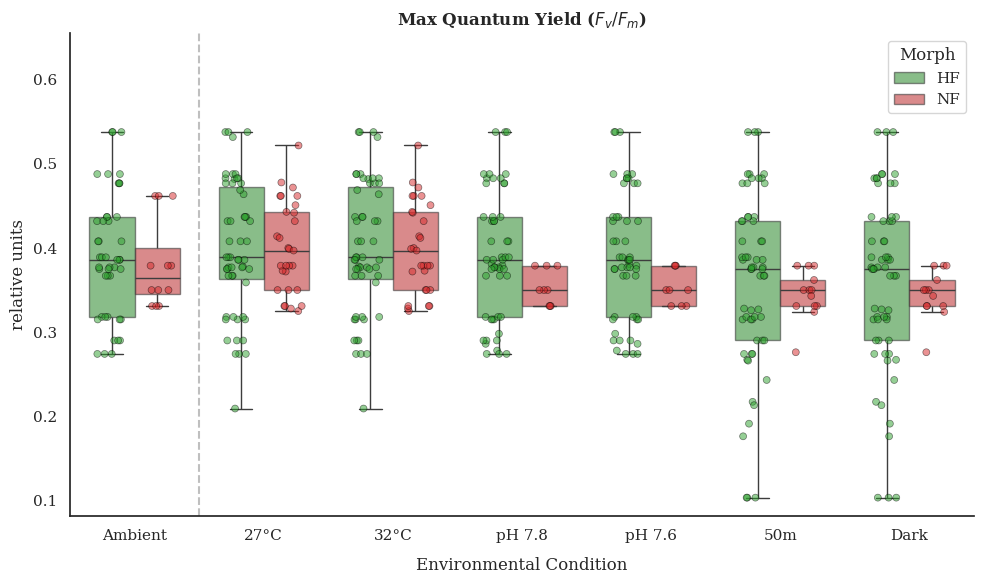

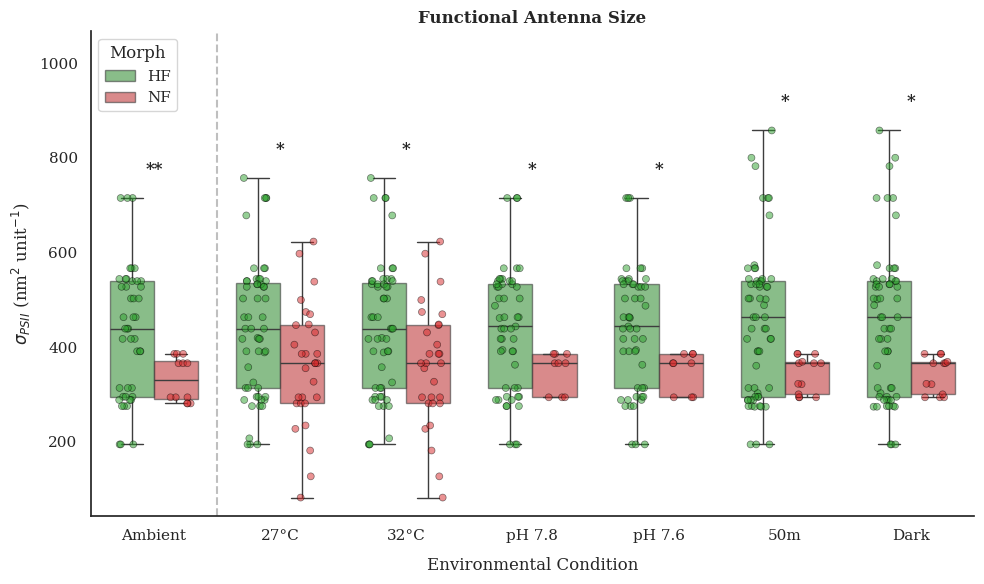

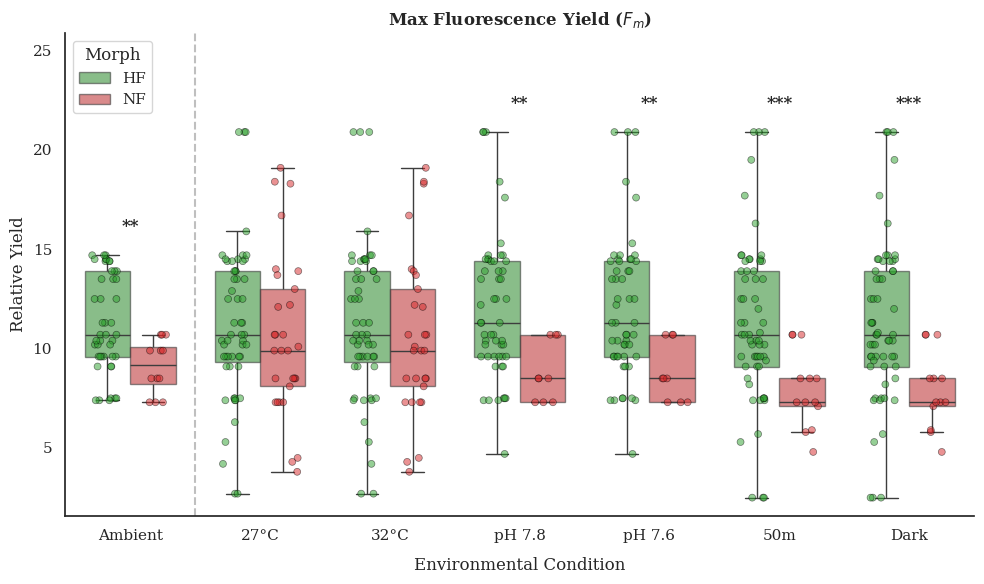

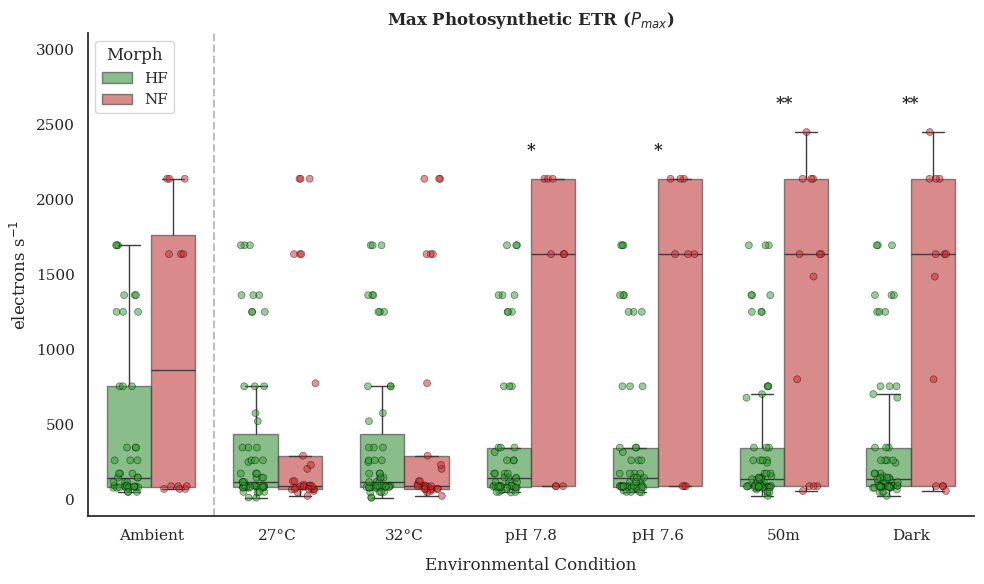

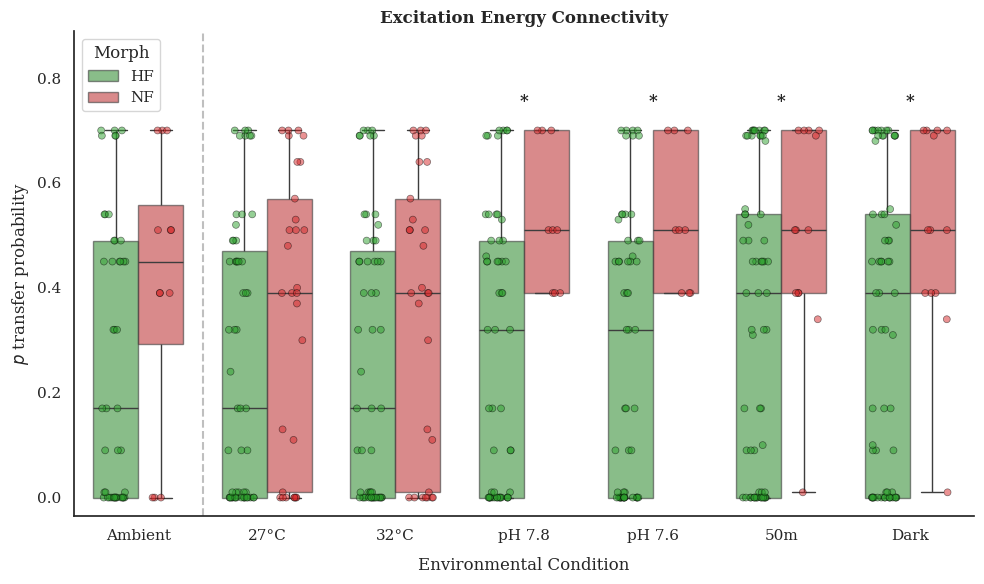

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Note: Global styling is now managed in the preceding configuration block (5uI2uGw_ZdDW)
sns.set_theme(style="white", font="serif")

plot_configs = [
    {'col': 'FvFm', 'label': 'relative units', 'title': 'Max Quantum Yield ($F_v/F_m$)'},
    {'col': 'Sigma', 'label': r'$\sigma_{PSII}$ (nm$^{2}$ unit$^{-1}$)', 'title': 'Functional Antenna Size'},
    {'col': 'Fm', 'label': 'Relative Yield', 'title': 'Max Fluorescence Yield ($F_m$)'},
    {'col': 'Pmax', 'label': 'electrons s$^{-1}$', 'title': 'Max Photosynthetic ETR ($P_{max}$)'},
    {'col': 'Connectivity', 'label': '$p$ transfer probability', 'title': 'Excitation Energy Connectivity'}
]

# Generate each plot as its own individual figure
for config in plot_configs:
    metric_col = config['col']
    if 'fire_clean' not in globals() or metric_col not in fire_clean.columns:
        continue

    fig, ax = plt.subplots(figsize=(10, 6))

    # Boxplot using global palette
    sns.boxplot(data=fire_clean, x='Condition', y=metric_col, hue='Morph',
                order=plot_order, hue_order=['HF', 'NF'], palette=variant_colors,
                ax=ax, width=0.7, boxprops=dict(alpha=0.6), showfliers=False)

    # Stripplot using GLOBAL artifact settings (jitter, size, alpha)
    sns.stripplot(data=fire_clean, x='Condition', y=metric_col, hue='Morph',
                  order=plot_order, hue_order=['HF', 'NF'], palette=variant_colors,
                  ax=ax, dodge=True, size=global_marker_size, alpha=global_alpha,
                  jitter=global_jitter, edgecolor='black', linewidth=0.5, legend=False)

    # Statistical Annotations
    y_min, y_max = ax.get_ylim()
    y_range = y_max - y_min
    ax.set_ylim(y_min, y_max + y_range * 0.2)

    for idx, cond in enumerate(plot_order):
        cond_data = fire_clean[fire_clean['Condition'] == cond]
        hf = cond_data[cond_data['Morph'] == 'HF'][metric_col].dropna()
        nf = cond_data[cond_data['Morph'] == 'NF'][metric_col].dropna()

        if len(hf) >= 3 and len(nf) >= 3:
            _, p1 = stats.shapiro(hf); _, p2 = stats.shapiro(nf)
            if p1 > 0.05 and p2 > 0.05:
                _, p_val = stats.ttest_ind(hf, nf, equal_var=False)
            else:
                _, p_val = stats.mannwhitneyu(hf, nf, alternative='two-sided')

            if p_val < 0.05:
                sig_text = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*"
                ax.text(idx, max(hf.max(), nf.max()) + (y_range*0.05), sig_text,
                        ha='center', va='bottom', fontweight='bold', family='serif')

    ax.set_title(config['title'], fontweight='bold', loc='center', family='serif')
    ax.set_xlabel("Environmental Condition", labelpad=10, family='serif')
    ax.set_ylabel(config['label'], family='serif')
    ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)

    sns.despine()
    plt.tight_layout()
    plt.show()

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- GLOBAL PLOT STYLING ---
plt.rcParams.update({
    "font.family": "Serif",
    "font.size": 14,          # Global text size
    "axes.titlesize": 16,     # Plot titles
    "axes.labelsize": 14,     # Axis labels
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

# --- GLOBAL COLOR PALETTE & PLOT ARTIFACTS ---
variant_colors = {'HF': '#2ca02c', 'NF': '#d62728'}
plot_order = ['Ambient', '27°C', '32°C', 'pH 7.8', 'pH 7.6', '50m', 'Dark']

# Standardized Dimensions and Aesthetics
global_fig_size = (10, 6)
global_jitter = 0.2
global_marker_size = 5
global_alpha = 0.5

sns.set_palette(list(variant_colors.values()))
print("Global styling, color palette, and plot artifacts (including size) initialized.")

Global styling, color palette, and plot artifacts (including size) initialized.


### Block 5b: Focused 3-Panel Physiology Summary
This block generates a horizontal summary figure featuring Sigma, Pmax, and Fv/Fm, optimized for a specific 3-panel layout.

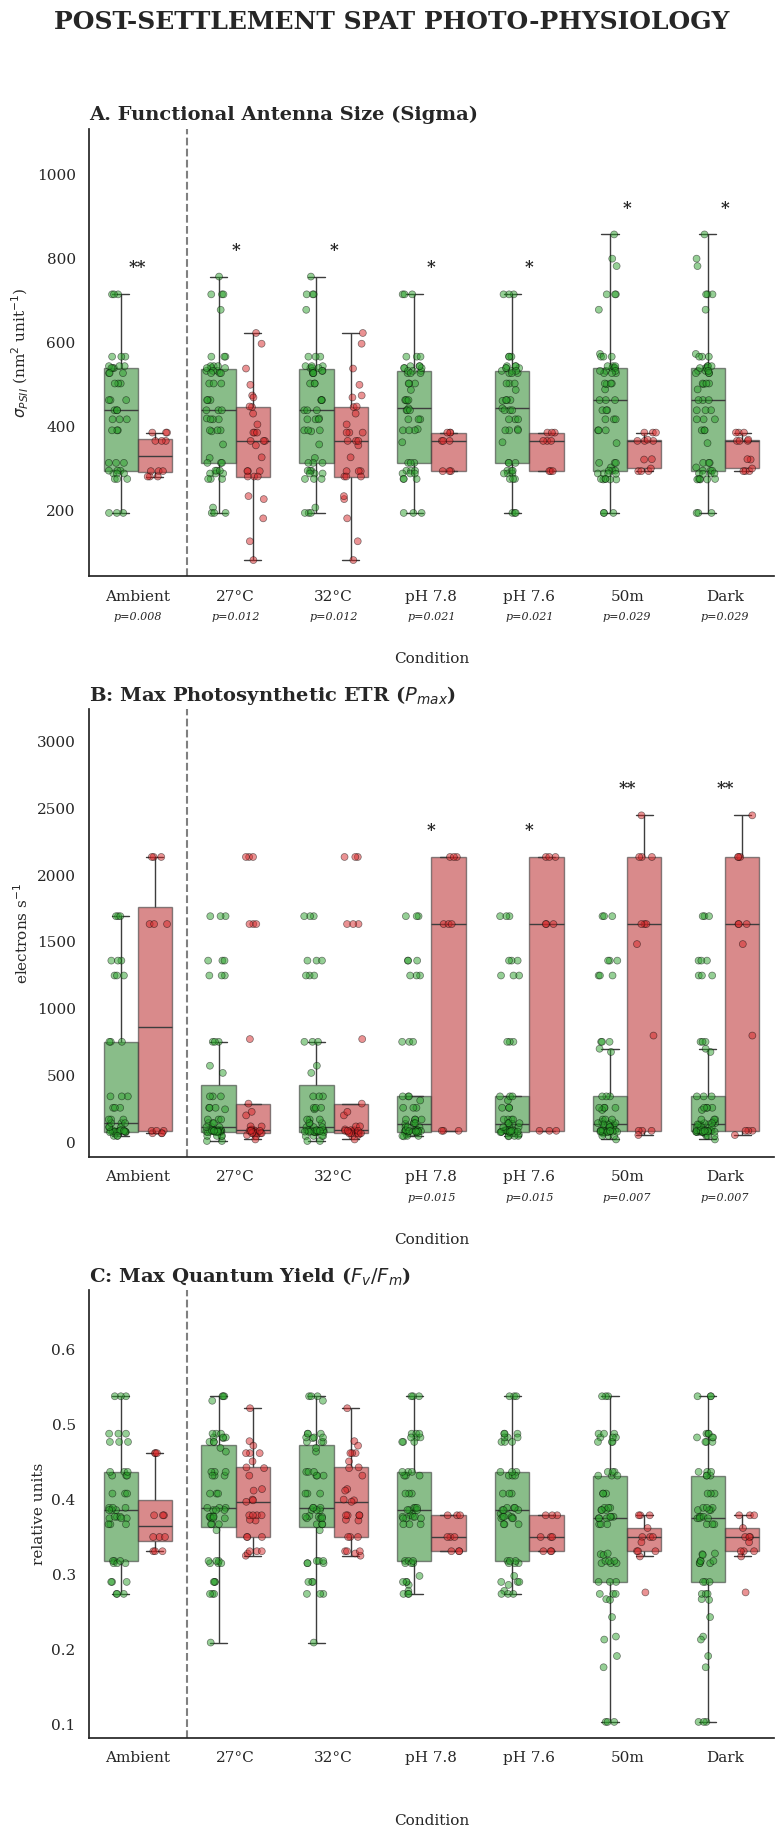

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

# --- VERTICAL 3-PANEL SUMMARY FIGURE ---
sns.set_theme(style="white", font="serif")

summary_configs = [
    {'col': 'Sigma', 'label': r'$\sigma_{PSII}$ (nm$^{2}$ unit$^{-1}$)', 'title': 'A. Functional Antenna Size (Sigma)'},
    {'col': 'Pmax', 'label': 'electrons s$^{-1}$', 'title': 'B: Max Photosynthetic ETR ($P_{max}$)'},
    {'col': 'FvFm', 'label': 'relative units', 'title': 'C: Max Quantum Yield ($F_v/F_m$)'}
]

fig, axes = plt.subplots(3, 1, figsize=(8, 18))
fig.suptitle('POST-SETTLEMENT SPAT PHOTO-PHYSIOLOGY', fontsize=18, fontweight='bold', family='serif', y=1.02)

for i, config in enumerate(summary_configs):
    ax = axes[i]
    metric_col = config['col']
    if metric_col not in fire_clean.columns: continue

    # Boxplots
    sns.boxplot(data=fire_clean, x='Condition', y=metric_col, hue='Morph', order=plot_order,
                hue_order=['HF', 'NF'], palette=variant_colors, ax=ax, width=0.7,
                boxprops=dict(alpha=0.6), showfliers=False, legend=False)

    # Stripplots using GLOBAL variables
    sns.stripplot(data=fire_clean, x='Condition', y=metric_col, hue='Morph', order=plot_order,
                  hue_order=['HF', 'NF'], palette=variant_colors, ax=ax, dodge=True,
                  size=global_marker_size, alpha=global_alpha, jitter=global_jitter,
                  edgecolor='black', linewidth=0.5, legend=False)

    # Stats
    y_min, y_max = ax.get_ylim()
    y_range = y_max - y_min
    ax.set_ylim(y_min, y_max + y_range * 0.25)

    for idx, cond in enumerate(plot_order):
        cond_data = fire_clean[fire_clean['Condition'] == cond]
        hf = cond_data[cond_data['Morph'] == 'HF'][metric_col].dropna()
        nf = cond_data[cond_data['Morph'] == 'NF'][metric_col].dropna()

        if len(hf) >= 3 and len(nf) >= 3:
            _, p1 = stats.shapiro(hf); _, p2 = stats.shapiro(nf)
            if p1 > 0.05 and p2 > 0.05: _, p_val = stats.ttest_ind(hf, nf, equal_var=False)
            else: _, p_val = stats.mannwhitneyu(hf, nf, alternative='two-sided')

            if p_val < 0.05:
                sig_text = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*"
                ax.text(idx, max(hf.max(), nf.max()) + (y_range*0.05), sig_text,
                        ha='center', va='bottom', fontweight='bold', family='serif')
                ax.text(idx, y_min - (y_range*0.1), f"p={p_val:.3f}" if p_val >= 0.001 else "p<0.001",
                        ha='center', va='top', fontsize=8, fontstyle='italic', family='serif', clip_on=False)

    ax.set_title(config['title'], fontsize=14, fontweight='bold', loc='left', family='serif')
    ax.set_xlabel("Condition", fontsize=11, labelpad=35, family='serif')
    ax.set_ylabel(config['label'], fontsize=11, family='serif')
    ax.axvline(x=0.5, color='gray', linestyle='--')

sns.despine()
plt.tight_layout()
plt.savefig("Spat_Physiology_Vertical.svg", format='svg', dpi=600, bbox_inches='tight')
plt.show()

### Block 5c: Individual Metric Publication Figures
This block generates standalone figures for each biophysical parameter. These are useful for granular analysis and individual export for supplemental figures.

Saved: Individual_Plot_FvFm.svg


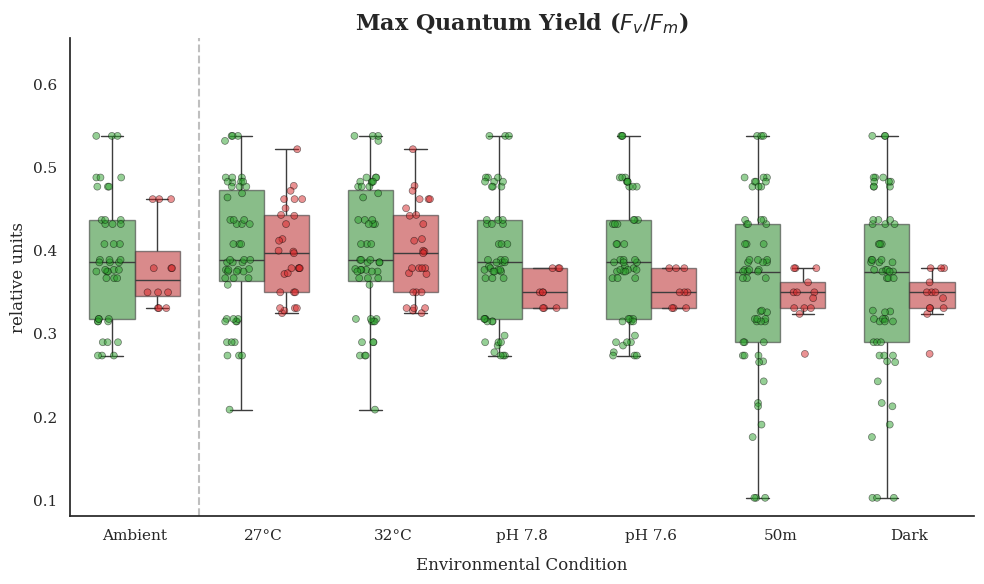

Saved: Individual_Plot_Sigma.svg


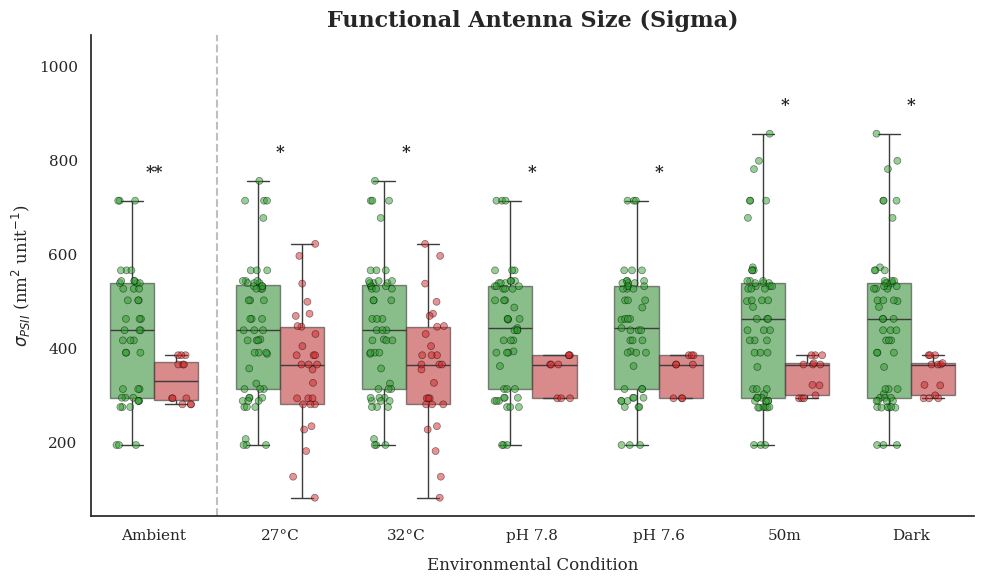

Saved: Individual_Plot_Fm.svg


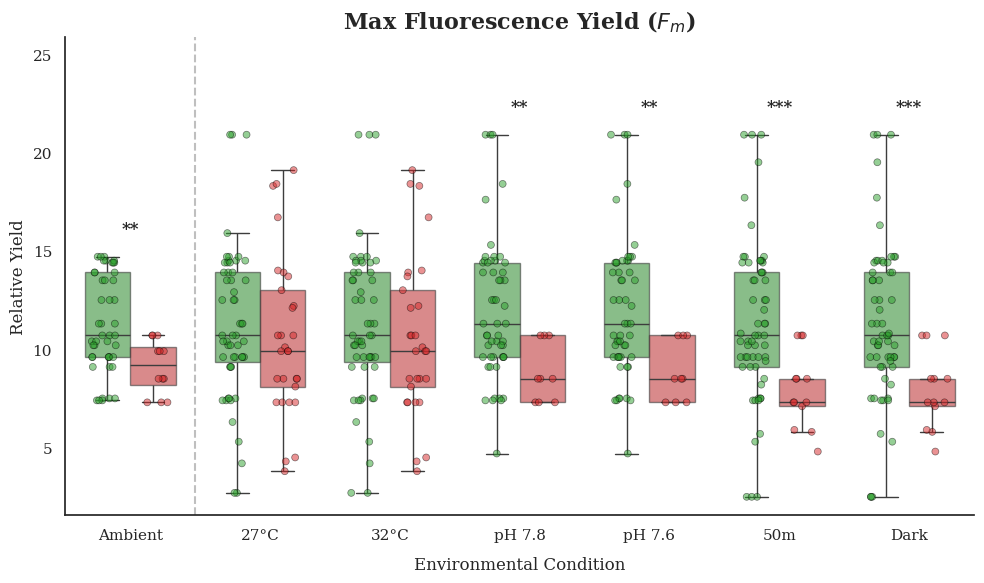

Saved: Individual_Plot_Pmax.svg


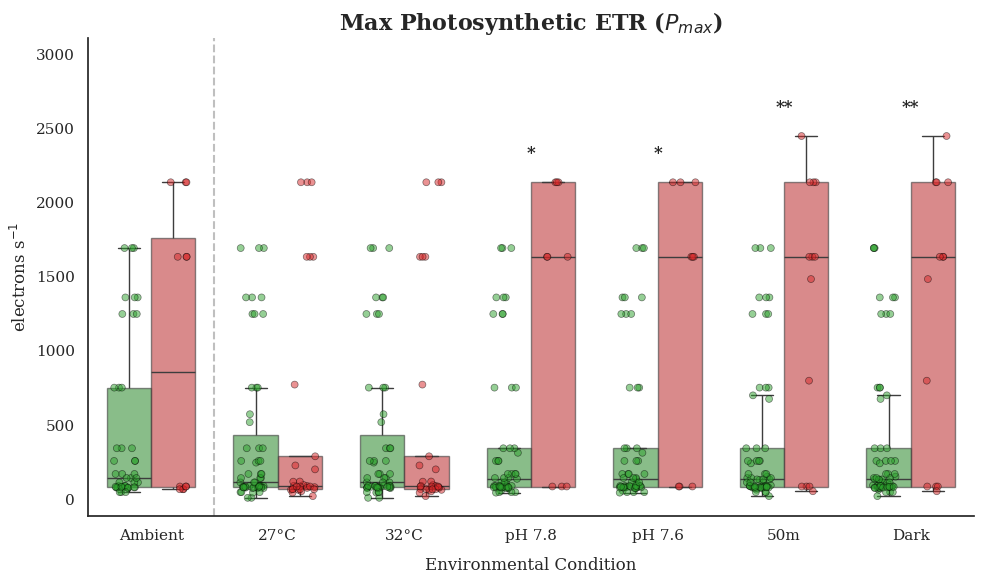

Saved: Individual_Plot_Connectivity.svg


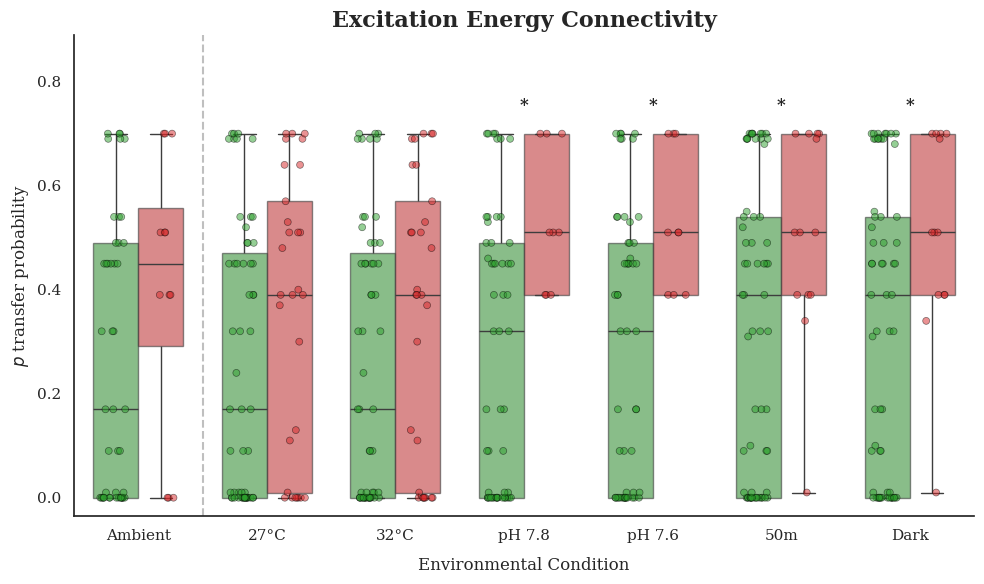

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Ensure theme is set to Serif
sns.set_theme(style="white", font="serif")

# List of all metrics to plot individually
individual_plot_configs = [
    {'col': 'FvFm', 'label': 'relative units', 'title': 'Max Quantum Yield ($F_v/F_m$)'},
    {'col': 'Sigma', 'label': r'$\sigma_{PSII}$ (nm$^{2}$ unit$^{-1}$)', 'title': 'Functional Antenna Size (Sigma)'},
    {'col': 'Fm', 'label': 'Relative Yield', 'title': 'Max Fluorescence Yield ($F_m$)'},
    {'col': 'Pmax', 'label': 'electrons s$^{-1}$', 'title': 'Max Photosynthetic ETR ($P_{max}$)'},
    {'col': 'Connectivity', 'label': '$p$ transfer probability', 'title': 'Excitation Energy Connectivity'}
]

for config in individual_plot_configs:
    metric_col = config['col']
    if metric_col not in fire_clean.columns:
        continue

    # Using GLOBAL figure size
    fig, ax = plt.subplots(figsize=global_fig_size)

    # Boxplot - Legend set to False
    sns.boxplot(data=fire_clean, x='Condition', y=metric_col, hue='Morph',
                order=plot_order, hue_order=['HF', 'NF'], palette=variant_colors,
                ax=ax, width=0.7, boxprops=dict(alpha=0.6), showfliers=False, legend=False)

    # Stripplot using GLOBAL variables
    sns.stripplot(data=fire_clean, x='Condition', y=metric_col, hue='Morph',
                  order=plot_order, hue_order=['HF', 'NF'], palette=variant_colors,
                  ax=ax, dodge=True, size=global_marker_size, alpha=global_alpha,
                  jitter=global_jitter, edgecolor='black', linewidth=0.5, legend=False)

    # Statistical Annotations
    y_min, y_max = ax.get_ylim()
    y_range = y_max - y_min
    ax.set_ylim(y_min, y_max + y_range * 0.2)

    for idx, cond in enumerate(plot_order):
        cond_data = fire_clean[fire_clean['Condition'] == cond]
        hf = cond_data[cond_data['Morph'] == 'HF'][metric_col].dropna()
        nf = cond_data[cond_data['Morph'] == 'NF'][metric_col].dropna()

        if len(hf) >= 3 and len(nf) >= 3:
            _, p1 = stats.shapiro(hf); _, p2 = stats.shapiro(nf)
            if p1 > 0.05 and p2 > 0.05:
                _, p_val = stats.ttest_ind(hf, nf, equal_var=False)
            else:
                _, p_val = stats.mannwhitneyu(hf, nf, alternative='two-sided')

            if p_val < 0.05:
                sig_text = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*"
                ax.text(idx, max(hf.max(), nf.max()) + (y_range*0.05), sig_text,
                        ha='center', va='bottom', fontweight='bold', family='serif')

    ax.set_title(config['title'], fontweight='bold', loc='center', family='serif', fontsize=16)
    ax.set_xlabel("Environmental Condition", labelpad=10, family='serif')
    ax.set_ylabel(config['label'], family='serif')
    ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)

    sns.despine()
    plt.tight_layout()

    # Save each plot with its metric name
    file_name = f"Individual_Plot_{metric_col}.svg"
    plt.savefig(file_name, format='svg', dpi=600, bbox_inches='tight')
    print(f"Saved: {file_name}")

    plt.show()

### Block 6: Reproducibility & Version Tracking
This block documents the specific software and library versions used to generate this analysis and the final figure.

In [10]:
import pandas as pd
import numpy as np
import scipy
import statsmodels
import matplotlib
import seaborn as sns
import sys

print("=== REPRODUCIBILITY REPORT ===")
print(f"Python version:      {sys.version.split()[0]}")
print(f"Pandas version:      {pd.__version__}")
print(f"NumPy version:       {np.__version__}")
print(f"SciPy version:       {scipy.__version__}")
print(f"Statsmodels version: {statsmodels.__version__}")
print(f"Matplotlib version:  {matplotlib.__version__}")
print(f"Seaborn version:     {sns.__version__}")
print("==============================")

=== REPRODUCIBILITY REPORT ===
Python version:      3.12.13
Pandas version:      2.2.2
NumPy version:       2.0.2
SciPy version:       1.16.3
Statsmodels version: 0.14.6
Matplotlib version:  3.10.0
Seaborn version:     0.13.2
